# Windrose Tilt Summaries

Direction and magnitude summaries for AE/CE tilt vectors.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
mag_bins = [0, 10, 20, 30, 40, np.inf]
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1


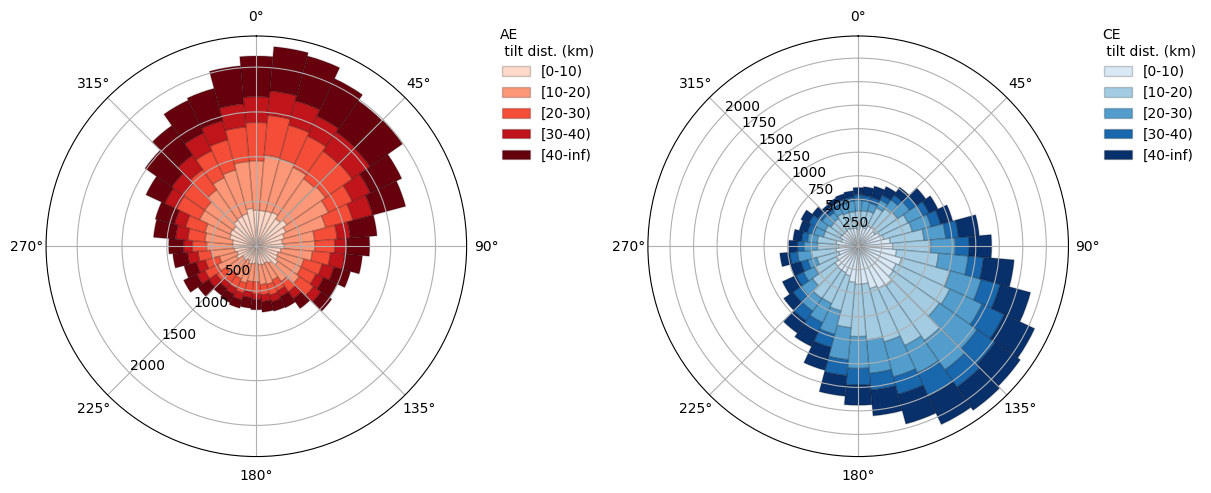

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    subset = subset[subset.Region.isin(['U1','U2','D1','D2'])]
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    # ax.set_rticks([])
plt.show()


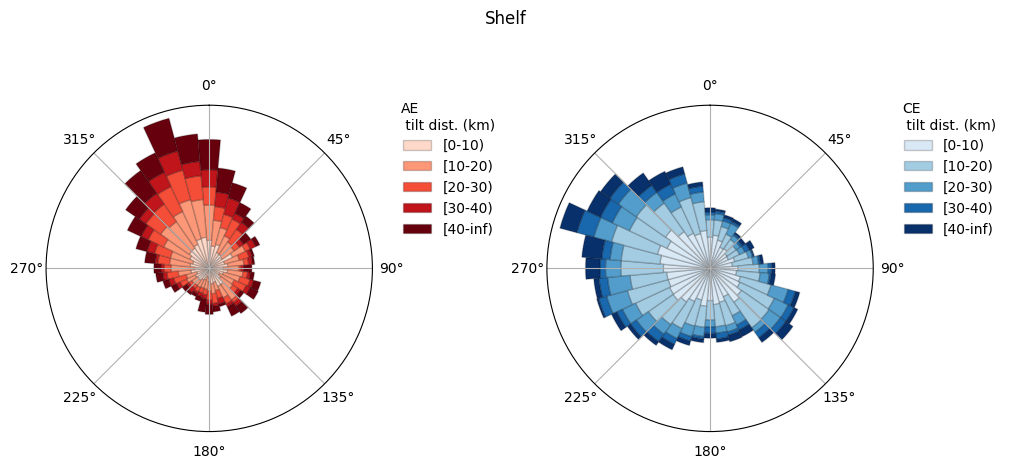

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    subset = subset[subset.Region.isin(['S1','S2'])]
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.suptitle('Shelf')
plt.show()

## Regional rose plot

This uses the shared `rose_plot` helper so the same regional windrose layout can be reused in other notebooks.


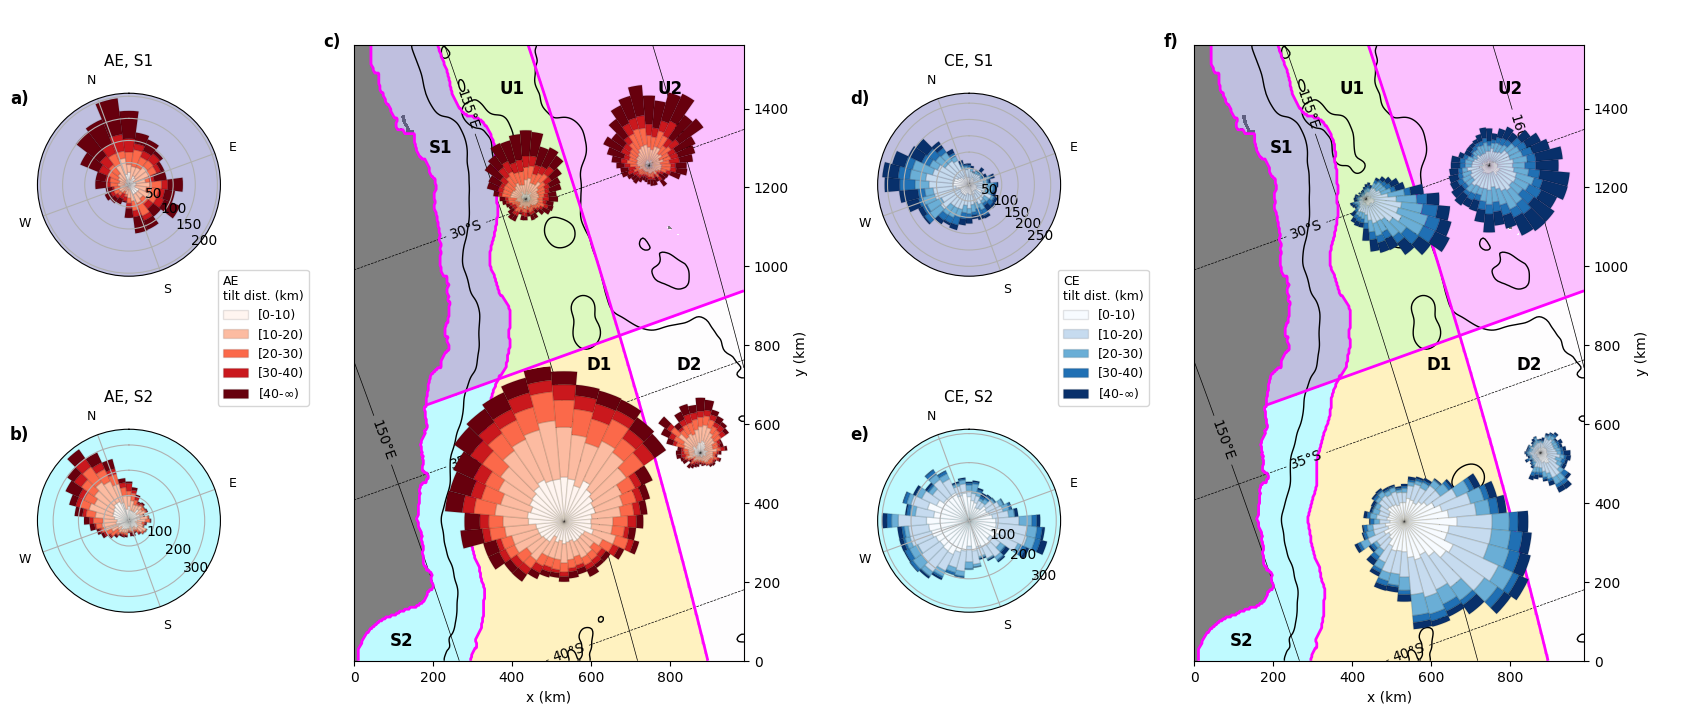

In [4]:
fig, rose = tilt.rose_plot(
    df_eddies,
    grid,
    mag="TiltDis",
    theta="TiltDir",
    mag_bins=mag_bins,
    frac=2.4,
    direction_offset=-20,
    shelf_offset=80,
    legend_title="tilt dist. (km)",
)


#### Rossby number

In [32]:
df_eddies['f'] = grid.f[df_eddies.ic, df_eddies.jc]
df_eddies['Ro'] = df_eddies["w"] / df_eddies["f"]

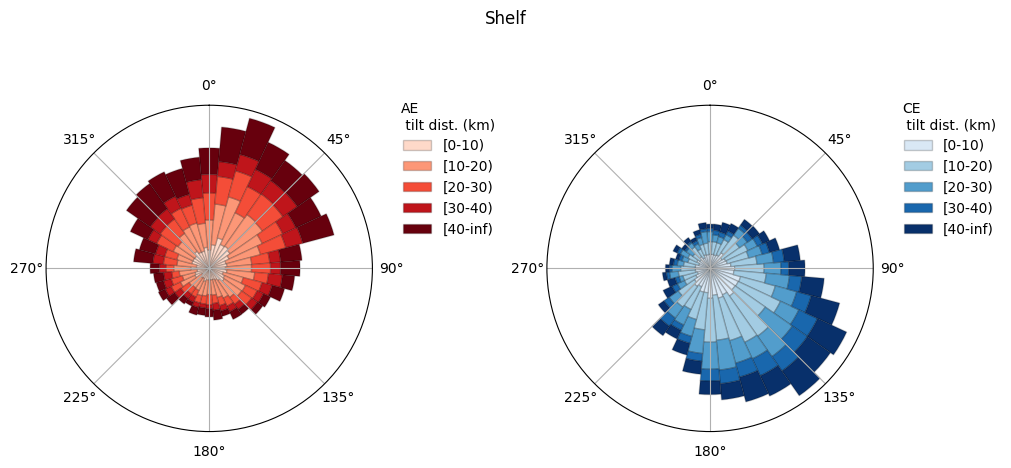

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    subset = subset[(subset.Region.isin(['U1','U2','D1','D2'])) & (subset.Ro.abs() < .2)]
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.suptitle('Shelf')
plt.show()

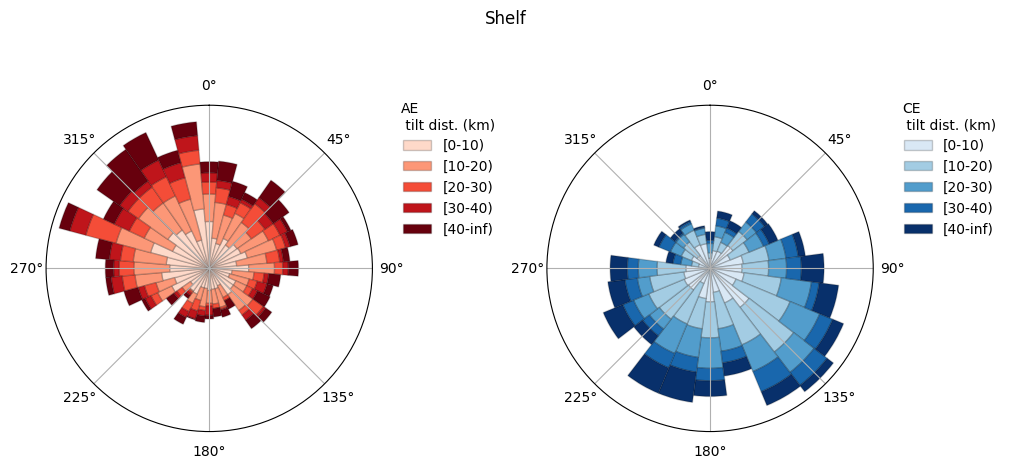

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    subset = subset[(subset.Region.isin(['U1','U2','D1','D2'])) & (subset.Ro.abs() > .5)]
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.suptitle('Shelf')
plt.show()

<Axes: >

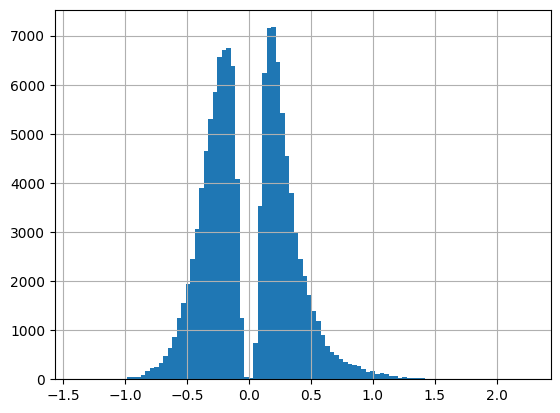

In [26]:
df_eddies.Ro.hist(bins=100)

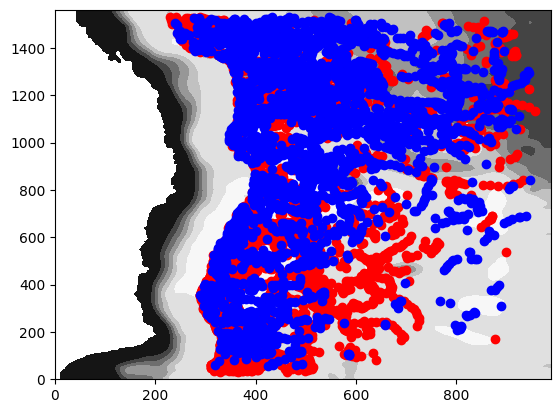

In [31]:
plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, grid.h, np.nan), cmap='Greys_r')
for cyc in ['AE', 'CE']:
    sub = df_eddies.copy()
    sub = sub[(sub.Region.isin(['U1','U2','D1','D2'])) & (sub.Ro.abs() > .5) & (sub.Cyc == cyc)]
    plt.scatter(sub.xc, sub.yc, color='r' if cyc=='AE' else 'b')

Cyc
AE    Axes(0.125,0.11;0.775x0.77)
CE    Axes(0.125,0.11;0.775x0.77)
Name: abs_vort, dtype: object

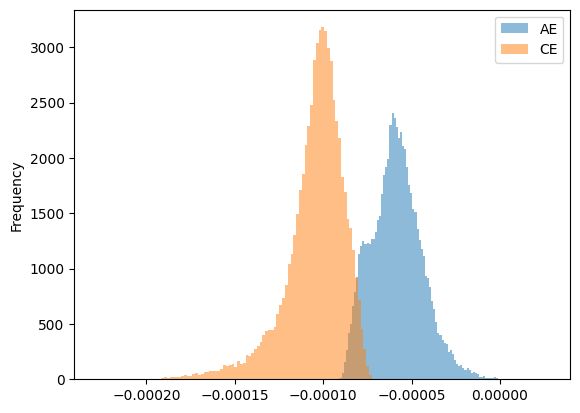

In [36]:
df_eddies['abs_vort'] = df_eddies.f + df_eddies.w
df_eddies.groupby('Cyc').abs_vort.plot.hist(bins=100, alpha=.5, legend=True)